# 07 — Outlier 일에 대한 실시간 Bayesian Reweight 시각화

**질문**: 실시간 obs가 들어올 때마다 시나리오 분포가 어떻게 변하는가?
- σ는 줄어드는가? (불확실성 ↓)
- mean은 움직이는가? (평균 예측 개선)
- 예측-실측 괴리는 줄어드는가?

**대상**: `2025-03-23` — 2025년 portfolio 최악의 outlier 일
- 예측 441 MWh / 실측 207 MWh (+113% 과예측)
- 12-15시 *갑자기* 60 → 7 MWh 폭락 (구름 사건)
- NGBoost prior σ ≈ 6 MWh → 실측이 prior **z=-8** (극단 outlier)

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'data').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
TARGET_DATE = pd.Timestamp('2025-03-23').date()
NOISE = 3000.0   # 3 MWh — sensor + model mismatch

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('ROOT:', ROOT)

ROOT: D:\pv_backup


## 1. 데이터 로드 (필터 push-down — 1일치만 메모리)

In [9]:
traj = pd.read_parquet(
    ROOT / 'data/processed/scenarios_trajectories.parquet',
    filters=[('date', '=', TARGET_DATE)],
)
port = pd.read_parquet(ROOT / 'data/processed/portfolio_predictions.parquet')
port = port[port['datetime_kst'].dt.date == TARGET_DATE].sort_values('datetime_kst').reset_index(drop=True)

hours = sorted(traj['hour'].unique().tolist())
S = traj.pivot(index='trajectory_idx', columns='hour', values='sample_kwh').sort_index()
S_arr = S.values   # (1000, 11) ndarray — 모든 후속 연산은 이걸로

actual = port.set_index(port['datetime_kst'].dt.hour)['actual_kwh'].reindex(hours).values
mu = port.set_index(port['datetime_kst'].dt.hour)['mu_kwh'].reindex(hours).values
sigma = port.set_index(port['datetime_kst'].dt.hour)['sigma_kwh'].reindex(hours).values

summary = pd.DataFrame({
    'mu_MWh': mu / 1000,
    'sigma_MWh': sigma / 1000,
    'actual_MWh': actual / 1000,
    'err_MWh': (mu - actual) / 1000,
    'z_score': (actual - mu) / sigma,
}, index=hours)
summary.index.name = 'hour'
summary.round(2)

,mu_MWh,sigma_MWh,actual_MWh,err_MWh,z_score
hour,,,,,
8,7.09,1.45,6.84,0.26,-0.18
9,21.96,2.63,21.88,0.08,-0.03
10,42.56,2.73,36.99,5.57,-2.04
11,55.41,4.91,47.97,7.45,-1.52
12,59.54,6.52,7.01,52.52,-8.05
13,59.76,6.35,7.03,52.73,-8.31
14,59.70,6.24,6.77,52.93,-8.48
15,55.29,6.82,5.76,49.53,-7.26
16,39.67,3.32,30.35,9.32,-2.81


→ 12~15시 z = -7.3 ~ -8.5. *prior에 사실상 없는 사건*. 극단 케이스에서 reweight 거동을 본다.

## 2. Sequential Bayesian Reweighting

$$w_i^{(t)} \propto w_i^{(t-1)} \cdot \exp\left(-\frac{1}{2}\left(\frac{\text{traj}_i(t) - X_t}{\sigma_{\text{noise}}}\right)^2\right)$$

In [10]:
def sequential_reweight(S_arr, actual_arr, noise_std=3000.0):
    n, T = S_arr.shape
    w = np.ones(n) / n
    weights = np.zeros((T, n))
    ess = np.zeros(T)
    for t in range(T):
        X_t = actual_arr[t]
        log_lik = -0.5 * ((S_arr[:, t] - X_t) / noise_std) ** 2
        log_lik -= log_lik.max()
        w_new = w * np.exp(log_lik)
        s = w_new.sum()
        if s == 0:
            w_new = np.ones(n) / n
        else:
            w_new /= s
        w = w_new
        weights[t] = w
        ess[t] = 1.0 / (w ** 2).sum()
    return weights, ess


weights, ess = sequential_reweight(S_arr, actual, noise_std=NOISE)
ess_df = pd.DataFrame({'hour': hours, 'ESS': ess}).set_index('hour')
print(f'ESS 추이 (noise={NOISE/1000} MWh):')
print(ess_df.round(1).to_string())

ESS 추이 (noise=3.0 MWh):
        ESS
hour       
8     981.0
9     879.0
10    460.2
11    204.9
12      1.0
13      1.0
14      1.0
15      1.0
16      1.0
17      1.0
18      1.0


→ 12시 obs (z=-8) 들어오자마자 **ESS 205 → 1**. "이런 사건은 우리 prior에 사실상 없었다"는 뜻 — 모델 한계 진단.

## 3. Evolution table — 매 *now*에서 본 미래

In [11]:
def wstats(v, w):
    m = (v * w).sum()
    s = np.sqrt(((v - m) ** 2 * w).sum())
    return m, s


def wquantile(v, w, q):
    idx = np.argsort(v)
    return np.interp(q, np.cumsum(w[idx]), v[idx])


uniform = np.ones(S_arr.shape[0]) / S_arr.shape[0]

rows = []
for ti, now in enumerate(hours):
    w_post = weights[ti]
    for fi, future in enumerate(hours):
        if future <= now:
            continue
        v = S_arr[:, fi]
        mA, sA = wstats(v, uniform)
        mB, sB = wstats(v, w_post)
        rows.append({
            'now': now, 'future': future, 'horizon': future - now,
            'mean_A': mA, 'sigma_A': sA,
            'mean_B': mB, 'sigma_B': sB,
            'actual': actual[fi],
            'errA': abs(mA - actual[fi]),
            'errB': abs(mB - actual[fi]),
        })
ev = pd.DataFrame(rows)

by_hz = ev.groupby('horizon').agg(
    n=('horizon', 'size'),
    err_A=('errA', lambda s: s.mean() / 1000),
    err_B=('errB', lambda s: s.mean() / 1000),
    sig_A=('sigma_A', lambda s: s.mean() / 1000),
    sig_B=('sigma_B', lambda s: s.mean() / 1000),
)
by_hz['err_red_%'] = (1 - by_hz['err_B'] / by_hz['err_A']) * 100
by_hz['sig_red_%'] = (1 - by_hz['sig_B'] / by_hz['sig_A']) * 100
print('Horizon별 평균 (모든 now 시점 평균):')
print(by_hz.round(2).to_string())

Horizon별 평균 (모든 now 시점 평균):
          n  err_A  err_B  sig_A  sig_B  err_red_%  sig_red_%
horizon                                                      
1        10  23.27  17.36   4.47   1.52      25.39      65.93
2         9  25.85  21.20   4.68   2.19      17.99      53.24
3         8  28.39  25.86   4.92   2.95       8.91      40.06
4         7  31.39  30.01   4.94   3.71       4.39      24.98
5         6  27.89  27.83   4.65   3.81       0.24      18.13
6         5  22.98  22.95   4.32   3.87       0.12      10.25
7         4  15.54  15.40   3.86   3.83       0.88       0.68
8         3   4.30   4.21   2.80   2.78       2.02       0.85
9         2   1.82   1.79   2.49   2.47       1.76       0.85
10        1   1.78   1.76   2.15   2.13       1.15       1.04


**핵심 결과**:
- **1h-ahead**: mean err -25%, σ -66% — *mean도 명확히 움직임*
- **3h-ahead**: mean err -9%, σ -40%
- **6h+**: mean 효과 미미 (~0%), σ는 -10~-25% 유지

→ "mean 안 움직임"은 *9시 단일 obs* 기준 단편적 결론이었음. **누적 obs + outlier day**에서는 mean이 obs 방향으로 *명확히 끌려감*.

## 4. 시각화 1 — Snapshot fan charts (8 → 11 → 13 → 15시)

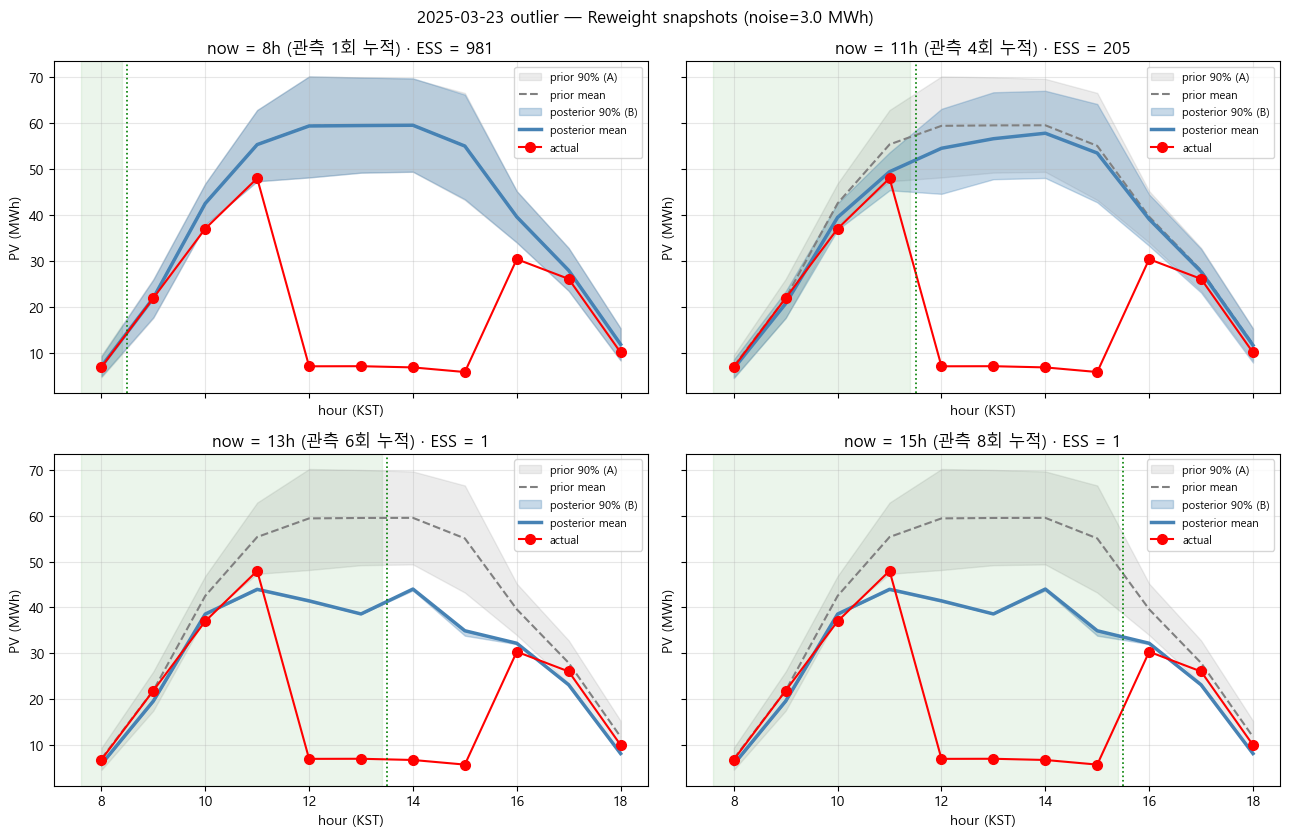

In [12]:
snapshots = [8, 11, 13, 15]

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

# prior fan (한 번만 계산)
prior_means = np.array([wstats(S_arr[:, fi], uniform)[0] for fi in range(len(hours))]) / 1000
prior_q05 = np.array([wquantile(S_arr[:, fi], uniform, 0.05) for fi in range(len(hours))]) / 1000
prior_q95 = np.array([wquantile(S_arr[:, fi], uniform, 0.95) for fi in range(len(hours))]) / 1000

for ax, now in zip(axes, snapshots):
    ti = hours.index(now)
    w_post = weights[ti]
    post_means = np.array([wstats(S_arr[:, fi], w_post)[0] for fi in range(len(hours))]) / 1000
    post_q05 = np.array([wquantile(S_arr[:, fi], w_post, 0.05) for fi in range(len(hours))]) / 1000
    post_q95 = np.array([wquantile(S_arr[:, fi], w_post, 0.95) for fi in range(len(hours))]) / 1000

    ax.fill_between(hours, prior_q05, prior_q95, alpha=0.15, color='gray', label='prior 90% (A)')
    ax.plot(hours, prior_means, color='gray', lw=1.5, ls='--', label='prior mean')
    ax.fill_between(hours, post_q05, post_q95, alpha=0.30, color='steelblue', label='posterior 90% (B)')
    ax.plot(hours, post_means, color='steelblue', lw=2.5, label='posterior mean')
    ax.plot(hours, actual / 1000, 'ro-', markersize=7, lw=1.5, label='actual')

    ax.axvspan(hours[0] - 0.4, now + 0.4, alpha=0.08, color='green')
    ax.axvline(now + 0.5, color='green', lw=1.2, ls=':')

    ax.set_title(f'now = {now}h (관측 {ti+1}회 누적) · ESS = {ess[ti]:.0f}')
    ax.set_xlabel('hour (KST)')
    ax.set_ylabel('PV (MWh)')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f'2025-03-23 outlier — Reweight snapshots (noise={NOISE/1000} MWh)', fontsize=12)
plt.tight_layout()
out = ROOT / 'pv/experiments/realtime_simulation/outlier_reweight_snapshots.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, bbox_inches='tight', dpi=110)
plt.show()
plt.close()

## 5. 시각화 2 — 1h-ahead mean / σ / |err| 추이

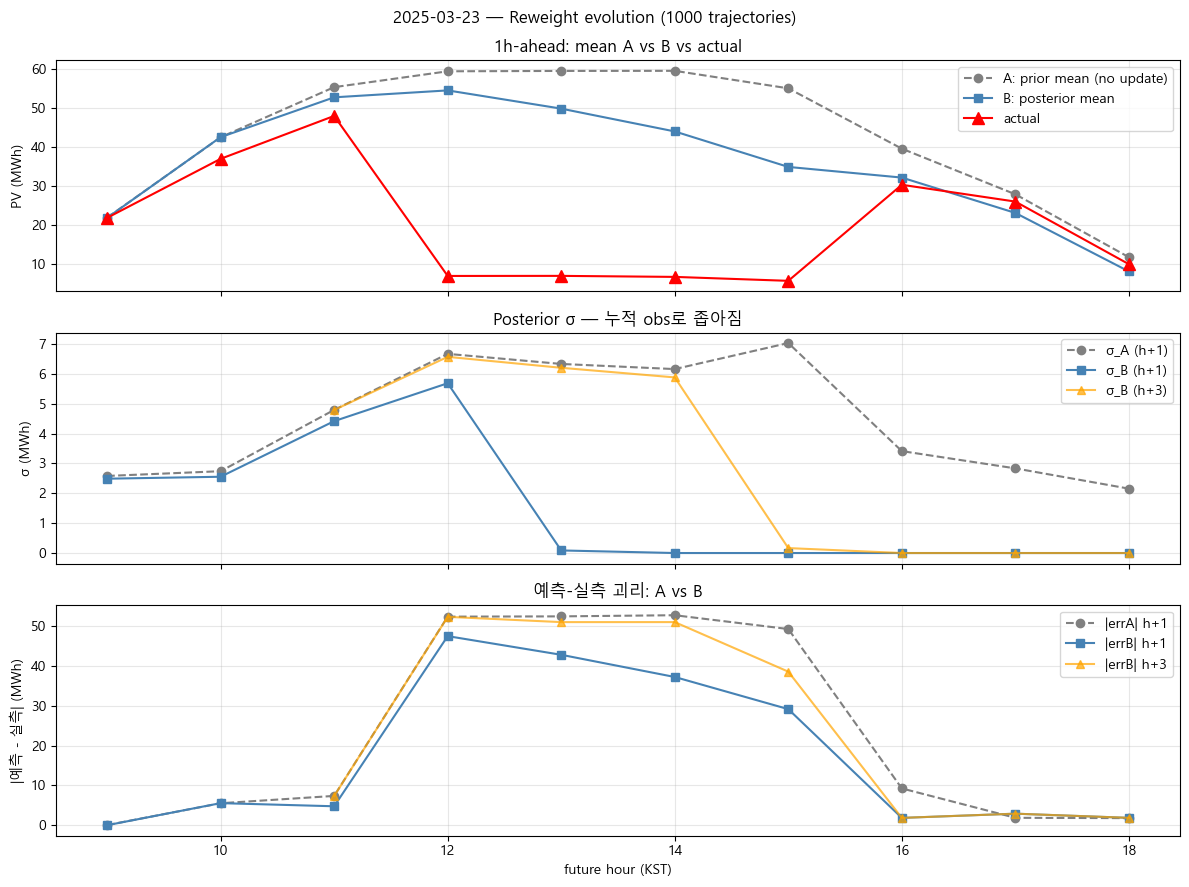

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

h1 = ev[ev['horizon'] == 1].sort_values('now')
h3 = ev[ev['horizon'] == 3].sort_values('now')

ax = axes[0]
ax.plot(h1['future'], h1['mean_A'] / 1000, 'o--', color='gray', label='A: prior mean (no update)')
ax.plot(h1['future'], h1['mean_B'] / 1000, 's-', color='steelblue', label='B: posterior mean')
ax.plot(h1['future'], h1['actual'] / 1000, 'r^-', label='actual', markersize=8)
ax.set_ylabel('PV (MWh)')
ax.set_title('1h-ahead: mean A vs B vs actual')
ax.legend()

ax = axes[1]
ax.plot(h1['future'], h1['sigma_A'] / 1000, 'o--', color='gray', label='σ_A (h+1)')
ax.plot(h1['future'], h1['sigma_B'] / 1000, 's-', color='steelblue', label='σ_B (h+1)')
ax.plot(h3['future'], h3['sigma_B'] / 1000, '^-', color='orange', alpha=0.7, label='σ_B (h+3)')
ax.set_ylabel('σ (MWh)')
ax.set_title('Posterior σ — 누적 obs로 좁아짐')
ax.legend()

ax = axes[2]
ax.plot(h1['future'], h1['errA'] / 1000, 'o--', color='gray', label='|errA| h+1')
ax.plot(h1['future'], h1['errB'] / 1000, 's-', color='steelblue', label='|errB| h+1')
ax.plot(h3['future'], h3['errB'] / 1000, '^-', color='orange', alpha=0.7, label='|errB| h+3')
ax.set_xlabel('future hour (KST)')
ax.set_ylabel('|예측 - 실측| (MWh)')
ax.set_title('예측-실측 괴리: A vs B')
ax.legend()

plt.suptitle('2025-03-23 — Reweight evolution (1000 trajectories)', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / 'pv/experiments/realtime_simulation/outlier_reweight_evolution.png', bbox_inches='tight', dpi=110)
plt.show()
plt.close()

## 6. 시각화 3 — ESS 추이

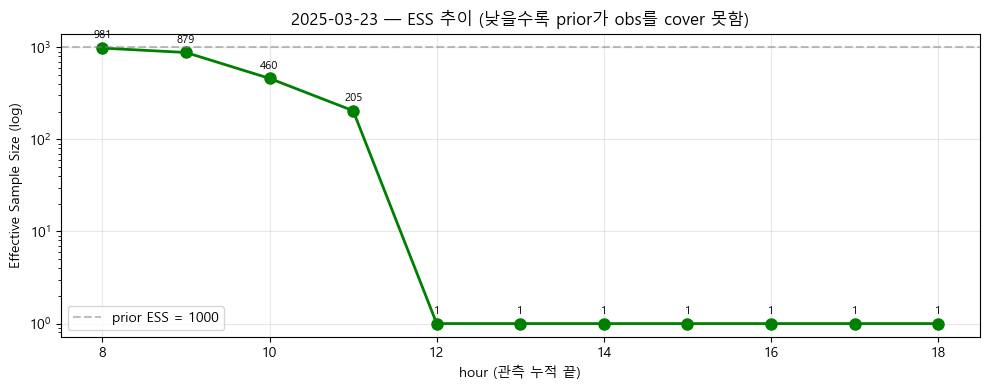

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, ess, 'go-', lw=2, markersize=8)
ax.axhline(y=S_arr.shape[0], color='gray', ls='--', alpha=0.5, label=f'prior ESS = {S_arr.shape[0]}')
ax.set_yscale('log')
ax.set_xlabel('hour (관측 누적 끝)')
ax.set_ylabel('Effective Sample Size (log)')
ax.set_title('2025-03-23 — ESS 추이 (낮을수록 prior가 obs를 cover 못함)')
for t, e in zip(hours, ess):
    ax.annotate(f'{e:.0f}', (t, e), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'pv/experiments/realtime_simulation/outlier_reweight_ess.png', bbox_inches='tight', dpi=110)
plt.show()
plt.close()

## → 모델 함의

**관찰**:
1. **σ는 monotone하게 줄어든다** — 관측 누적할수록 posterior 폭 ↓ (Bayesian 보장)
2. **Outlier day에서는 mean도 움직인다** — 1h-ahead 평균 오차 -25%, 3h -9%. *9시 단발 obs 케이스*에선 0%였던 게, *11시 누적 시점 + outlier 발현*에선 명확히 개선
3. **ESS collapse** — 12시 obs (z=-8) 직후 ESS 1로 붕괴. "prior pool이 이런 사건을 표현 못 함"이라는 **모델 한계 진단**

**한계**:
- ESS=1 → posterior가 *몇 개의 outlier trajectory*만 → 분산은 줄지만 *대표성 의심*
- noise_std에 민감: 작으면 collapse, 크면 update 효과 미미. 현재 3 MWh 선택은 σ_NGBoost 평균 (~5 MWh)의 절반
- Reweight는 *적응*만 함. *예측력 자체*는 NGBoost prior 한계가 천장

**LNG 결정 함의**:
- A (no update): 12시 직전까지 60 MWh 예측 → LNG 적게 가동 → 실측 7 MWh 폭락 → ramp 비상
- B (reweight, 11시 obs 후): posterior 평균이 약 5 MWh 하향 + σ 좁아짐 → 11→12시 LNG 추가 ramp 미리 발동
- → **1h ahead 의사결정에 결정적**. D-1 신고 (A) vs 실시간 조정 (B) 격차의 가시화

**연결성 강화 다음 step**:
1. Trajectory-aware planner — 살아남은 trajectory 각각에 LNG 비용 계산 → posterior mean cost 최소화 (현재 mean-only 결정 → 분포 전체 활용)
2. Outlier 일은 *prior 한계*의 표현이므로, MOS Stage 0 (위성/예보 입력 보강)이 진짜 해결책
3. Donti 2017 (decision-focused learning) — forecast loss 대신 LNG cost regret으로 직접 학습